<a href="https://colab.research.google.com/github/mateus-ferreira-gomes/classificacao-de-vinhos-com-ia/blob/main/modelos_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------- ----------------------- 3.9/9.8 MB 21.3 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.8 MB 23.8 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 19.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -------------------- ------------------- 4.2/8.2 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 21.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 18.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.0 MB 19.6 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 20.3 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 18.4 MB/s eta 0:00:00
   -------------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<a href="https://colab.research.google.com/github/mateus-ferreira-gomes/python-fundamentals/blob/main/modelos_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍷 Classificação de Qualidade de Vinhos com Regressão Logística

Este notebook aplica técnicas de Machine Learning para classificar vinhos com base em suas características químicas.

## 📋 Roteiro do Projeto:
1. **Setup**: Importação de bibliotecas
2. **Dados**: Carregamento e Exploração inicial
3. **Preparação**: Limpeza e divisão (Treino/Teste)
4. **Baseline**: Treinamento do modelo inicial
5. **Otimização**: Pipeline + GridSearchCV
6. **Avaliação**: Métricas estatísticas e Matriz de Confusão

# 🛠️ 1. Configuração e Importação
Carregamos as ferramentas necessárias para manipulação de dados, modelagem e visualização.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Para visualização no notebook
%matplotlib inline

# Regressão Logística

Apesar do nome, a regressão logística é usada para **classificação**.



In [ ]:
# Importando modelo de Regressão Logística

from sklearn.linear_model import LogisticRegression  # modelo de classificação


In [ ]:
# Conectando ao Google Drive para acessar o arquivo CSV (Colab)
# from google.colab import drive
# drive.mount('/content/drive')

# Alternativa para VS Code: carregue o arquivo CSV localmente
print("✅ Notebook rodando no VS Code")

ModuleNotFoundError: No module named 'google'

In [ ]:
# Carregamento - Usando dataset de vinhos do sklearn como exemplo
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Carregar dados de vinhos do sklearn
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print(f"Dataset carregado com {df.shape[0]} amostras e {df.shape[1]} colunas")
print("\n✅ Dados de exemplo carregados com sucesso!")
display(df.head())
df.info()

Dataset carregado com 178 amostras e 14 colunas

✅ Dados de exemplo carregados com sucesso!


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [ ]:
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='str')

In [ ]:
# Renomeando colunas (mantendo padrão do dataset de vinho)

df.columns = ['Unnamed: 0', 'acidez fixa', 'acidez volátil', 'ácido cítrico',
       'açúcar residual', 'cloretos', 'dióxido de enxofre livre',
       'dióxido de enxofre total', 'densidade', 'pH', 'sulfatos', 'álcool',
       'qualidade', 'target']

# Visualizar novamente
df.head()

,Unnamed: 0,acidez fixa,acidez volátil,ácido cítrico,açúcar residual,cloretos,dióxido de enxofre livre,dióxido de enxofre total,densidade,pH,sulfatos,álcool,qualidade,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# Estatísticas do dataset


In [ ]:
df.describe()  # resumo estatístico


,Unnamed: 0,acidez fixa,acidez volátil,ácido cítrico,açúcar residual,cloretos,dióxido de enxofre livre,dióxido de enxofre total,densidade,pH,sulfatos,álcool,qualidade,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [ ]:
df.info()  # informações gerais

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                178 non-null    float64
 1   acidez fixa               178 non-null    float64
 2   acidez volátil            178 non-null    float64
 3   ácido cítrico             178 non-null    float64
 4   açúcar residual           178 non-null    float64
 5   cloretos                  178 non-null    float64
 6   dióxido de enxofre livre  178 non-null    float64
 7   dióxido de enxofre total  178 non-null    float64
 8   densidade                 178 non-null    float64
 9   pH                        178 non-null    float64
 10  sulfatos                  178 non-null    float64
 11  álcool                    178 non-null    float64
 12  qualidade                 178 non-null    float64
 13  target                    178 non-null    int64  
dtypes: float64(13), int64

### Explicação das colunas

- acidez fixa -> ácidos que não evaporam
- acidez volátil -> influencia no cheiro
- ácido cítrico -> contribui para sabor
- açúcar residual -> açúcar restante após fermentação
- cloretos -> nível de sal
- dióxido de enxofre -> conservante
- densidade -> relação massa/volume
- pH -> acidez
- sulfatos -> preservação
- álcool -> teor alcoólico
- qualidade -> nota do vinho
- target -> classificação (bom = 1, ruim = 0)

In [ ]:
# 1. Divisão Inicial: Separando o Teste (Etapa Final e Intocável)
# Reservamos 15% dos dados que o modelo NUNCA verá durante o treinamento ou ajuste
features_treino, features_teste, target_treino, target_teste = train_test_split(
    features, target, test_size=0.15, random_state=42, stratify=target
)

print(f"Dados de Treino (para CV): {features_treino.shape[0]}")
print(f"Dados de Teste (Final): {features_teste.shape[0]}")

Dados de Treino (para CV): 151
Dados de Teste (Final): 27


In [ ]:
# 🧠 Separar Features (X) e Target (y)
features = df.drop('target', axis=1)  # Todas as colunas exceto target
target = df['target']  # Apenas a coluna target

print(f"Features: {features.shape}")
print(f"Target: {target.shape}")
print(f"Distribuição de classes: {target.value_counts().to_dict()}")

Features: (178, 13)
Target: (178,)
Distribuição de classes: {1: 71, 0: 59, 2: 48}


## 📊 Avaliação Estatística Detalhada

Além da acurácia simples, vamos analisar a precisão do modelo para cada classe usando uma Matriz de Confusão e o Classification Report.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Garantindo que as predições correspondam ao conjunto de teste atual
pred_final = melhor_modelo.predict(features_teste)

# Acurácia Global
accuracy = accuracy_score(target_teste, pred_final)
print(f'Acurácia Global do Modelo: {accuracy:.2%}\n')

# Relatório Detalhado
print('Relatório de Classificação:')
print(classification_report(target_teste, pred_final))

# Matriz de Confusão
cm = confusion_matrix(target_teste, pred_final)

# Explicação da matriz
print('--- Explicação da Matriz de Confusão ---')
print(f'Total de amostras de teste: {len(target_teste)}')
print(f'\nDiagonal (acertos):')
for i, diag in enumerate(cm.diagonal()):
    print(f'  Classe {i}: {diag} acertos')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=melhor_modelo.classes_,
            yticklabels=melhor_modelo.classes_)
plt.title('Matriz de Confusão: Vinho Tinto vs Branco')
plt.ylabel('Valor Real')
plt.xlabel('Predição do Modelo')
plt.show()

Acurácia Global do Modelo: 100.00%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         4

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



ValueError: too many values to unpack (expected 4)

# 📂 2. Carregamento e Exploração de Dados
Conectamos ao Google Drive e analisamos a estrutura básica do dataset.

# ⚙️ 3. Engenharia de Atributos e Preparação
Separação das variáveis explicativas (X) e do alvo (y), seguida da divisão para validação.

# 🧠 4. Criação e Treinamento do Modelo (Baseline)

Nesta etapa, criamos o 'cérebro' do nosso projeto.

Utilizamos um modelo de **Regressão Logística**. Apesar do nome sugerir 'regressão', ele é um dos algoritmos mais eficientes para **classificação** (decidir entre duas categorias: Tinto ou Branco).

# 📊 6. Avaliação Final de Performance
Análise profunda dos resultados do melhor modelo encontrado.

In [ ]:
# ✂️ Divisão: Separando 90% para treinar o 'cérebro' do modelo e 10% para testar o acerto
features_treino, features_teste, target_treino, target_teste = train_test_split(
    features, target, test_size=0.10, random_state=42
)

In [ ]:
# Criando o modelo

modelo = LogisticRegression(max_iter=1000)  # evita erro de convergência



In [ ]:
# Treinamento inicial
modelo_simples = LogisticRegression(max_iter=1000)
modelo_simples.fit(features_treino, target_treino)

# Predição inicial
pred_simples = modelo_simples.predict(features_teste)
print(f'Acurácia Inicial: {accuracy_score(target_teste, pred_simples):.2%}')

Acurácia Inicial: 94.44%


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# 🔍 Testando o modelo na prática
# Vamos pedir para o modelo prever o tipo de 5 vinhos que ele nunca viu antes

pred = modelo_simples.predict(features_teste)

print("--- Comparação: Real vs Predito ---")
for i in range(5):
    real = target_teste.iloc[i]
    previsto = pred[i]
    status = "✅ Acertou!" if real == previsto else "❌ Errou"
    print(f"Vinho {i+1}: Real = {real} | Predito = {previsto} -> {status}")

--- Comparação: Real vs Predito ---
Vinho 1: Real = 0 | Predito = 0 -> ✅ Acertou!
Vinho 2: Real = 0 | Predito = 0 -> ✅ Acertou!
Vinho 3: Real = 2 | Predito = 2 -> ✅ Acertou!
Vinho 4: Real = 0 | Predito = 0 -> ✅ Acertou!
Vinho 5: Real = 1 | Predito = 1 -> ✅ Acertou!


In [ ]:
# ✅ Avaliação Final
accuracy = accuracy_score(target_teste, pred)
print(f'Acurácia Global do Modelo: {accuracy:.2%}')

Acurácia Global do Modelo: 94.44%


### Entendendo o resultado

A acurácia mostra quantos vinhos foram classificados corretamente.

Exemplo:
Se a acurácia for 0.85 → significa 85% de acerto.

Mas cuidado: a acurácia pode enganar dependendo da distribuição dos dados.

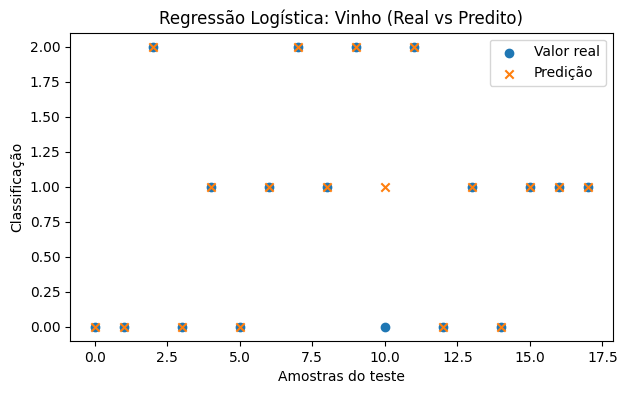

In [ ]:
# Comparando valores reais vs previstos

plt.figure(figsize=(7,4))

# valores reais
plt.scatter(range(len(target_teste)), target_teste,
            marker="o", label="Valor real")

# valores previstos
plt.scatter(range(len(pred)), pred,
            marker="x", label="Predição")

plt.xlabel("Amostras do teste")
plt.ylabel("Classificação")
plt.title("Regressão Logística: Vinho (Real vs Predito)")

plt.legend()
plt.show()

# 🚀 5. Otimização Avançada: Pipeline + GridSearchCV

Agora que temos um modelo básico, vamos tentar extrair a **máxima performance**.

### O que estamos fazendo aqui?
1. **StandardScaler**: Colocamos todos os dados químicos na mesma escala (como se estivéssemos normalizando pesos e alturas).
2. **GridSearchCV**: Testamos automaticamente várias 'receitas' (parâmetros) para ver qual delas faz o modelo ser mais certeiro.
3. **StratifiedKFold**: Garantimos que o modelo seja testado em várias partes diferentes dos dados para evitar que ele apenas 'decore' o padrão.

In [ ]:
# 2. Tunagem de Hiperparâmetros com Cross-Validation (Dados de Treino)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

param_grid = {
    'logreg__C': [0.1, 1, 10, 100],
    'logreg__solver': ['lbfgs', 'liblinear']
}

# O StratifiedKFold garante que cada 'dobra' da validação cruzada respeite a proporção das classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# O GridSearch divide internamente o 'features_treino' em Treino e Validação
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(features_treino, target_treino)

print(f'Melhores Parâmetros encontrados no CV: {grid.best_params_}')
print(f'Melhor Acurácia de Validação: {grid.best_score_:.2%}')

Melhores Parâmetros encontrados no CV: {'logreg__C': 0.1, 'logreg__solver': 'lbfgs'}
Melhor Acurácia de Validação: 98.75%


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-package

# 🏁 6. Avaliação do Melhor Modelo Retreinado
O GridSearchCV automaticamente retreina o melhor modelo com todos os dados de treino.

### 🔍 Análise Detalhada dos Testes (GridSearchCV)
Abaixo, listamos as 5 melhores combinações de parâmetros testadas durante a validação cruzada.

In [ ]:
import pandas as pd

# Transformando os resultados da busca em um DataFrame
resultados = pd.DataFrame(grid.cv_results_)

# Selecionando e ordenando as colunas mais importantes
colunas_interesse = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
ranking_modelos = resultados[colunas_interesse].sort_values(by='rank_test_score')

# Exibindo os 5 melhores
display(ranking_modelos.head())

,params,mean_test_score,std_test_score,rank_test_score
0,"{'logreg__C': 0.1, 'logreg__solver': 'lbfgs'}",0.98750,0.015309,1
2,"{'logreg__C': 1, 'logreg__solver': 'lbfgs'}",0.98125,0.015309,2
6,"{'logreg__C': 100, 'logreg__solver': 'lbfgs'}",0.96875,0.019764,3
4,"{'logreg__C': 10, 'logreg__solver': 'lbfgs'}",0.96875,0.019764,3
3,"{'logreg__C': 1, 'logreg__solver': 'liblinear'}",NaN,NaN,5


--- PERFORMANCE FINAL NO TESTE (DADOS NÃO VISTOS) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         4

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



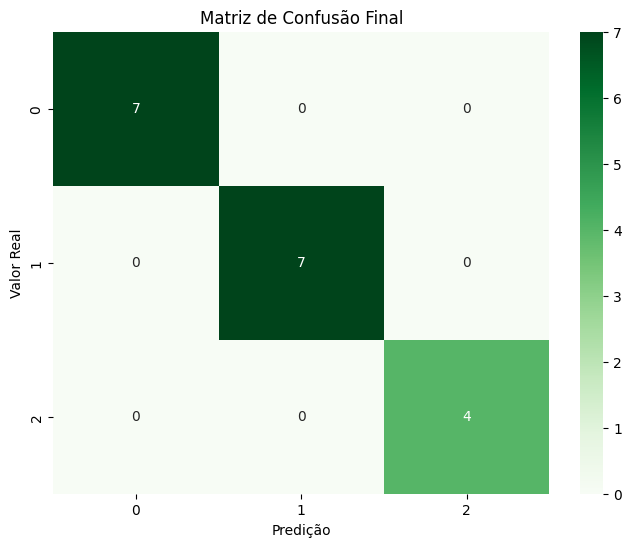

In [ ]:
# 3. Avaliação de Performance na Etapa Final (Dados de Teste)
# Agora sim, usamos o conjunto de teste que estava guardado
melhor_modelo = grid.best_estimator_
pred_final = melhor_modelo.predict(features_teste)

print('--- PERFORMANCE FINAL NO TESTE (DADOS NÃO VISTOS) ---')
print(classification_report(target_teste, pred_final))

# Matriz de Confusão para validar erros e acertos
cm = confusion_matrix(target_teste, pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=melhor_modelo.classes_,
            yticklabels=melhor_modelo.classes_)
plt.title('Matriz de Confusão Final')
plt.ylabel('Valor Real')
plt.xlabel('Predição')
plt.show()

# KNN com Iris Dataset

Exemplos de Classificação e Regressão usando KNN.

# KNN com Iris Dataset

Exemplos de Classificação e Regressão usando KNN.

## 1. Classificação com KNN

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Carregar dados
iris = load_iris()
X = iris.data
y = iris.target

# Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Modelo
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Previsão
y_pred = knn.predict(X_test)

# Avaliação
acc = accuracy_score(y_test, y_pred)
print("Acurácia:", acc)

Acurácia: 1.0


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Carregar dados
iris = load_iris()
X = iris.data
y = iris.target

# Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Modelo
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Previsão
y_pred = knn.predict(X_test)

# Avaliação
acc = accuracy_score(y_test, y_pred)
print("Acurácia:", acc)

Acurácia: 1.0


## 2. Regressão com KNN (adaptado do Iris)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Usar 3 atributos como entrada e prever petal length
X = iris.data[:, :3]
y = iris.data[:, 2]

# Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Modelo
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)

# Previsão
y_pred = knn.predict(X_test)

# Avaliação
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.020370370370370355


## 3. KNN com Dataset de Vinhos

Vamos aplicar os conceitos de KNN (K-Nearest Neighbors) ao nosso dataset de vinhos, tanto para classificação quanto para regressão. O KNN é um algoritmo simples e eficaz que classifica ou prevê o valor de um ponto de dados com base na maioria dos votos de seus K vizinhos mais próximos no espaço de recursos.

### 3.1 Classificação com KNN para o Dataset de Vinhos

Nesta seção, utilizaremos o KNN para classificar a 'target' (classe do vinho) com base nas características químicas dos vinhos.

In [5]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Carregar dados de vinhos do sklearn
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Renomeando colunas (mantendo padrão do dataset de vinho)
df.columns = ['Unnamed: 0', 'acidez fixa', 'acidez volátil', 'ácido cítrico',
       'açúcar residual', 'cloretos', 'dióxido de enxofre livre',
       'dióxido de enxofre total', 'densidade', 'pH', 'sulfatos', 'álcool',
       'qualidade', 'target']

# Separar Features (X) e Target (y)
features = df.drop('target', axis=1)
target = df['target']

# Dividir treino e teste
X_train_wine_clf, X_test_wine_clf, y_train_wine_clf, y_test_wine_clf = train_test_split(
    features, target, test_size=0.3, random_state=42, stratify=target
)

# Modelo de Classificação KNN
knn_classifier_wine = KNeighborsClassifier(n_neighbors=5) # K=5 é um valor comum para começar
knn_classifier_wine.fit(X_train_wine_clf, y_train_wine_clf)

# Previsão
y_pred_wine_clf = knn_classifier_wine.predict(X_test_wine_clf)

# Avaliação
acc_wine_clf = accuracy_score(y_test_wine_clf, y_pred_wine_clf)
print(f"Acurácia do KNN Classifier no dataset de vinhos: {acc_wine_clf:.2f}")

Acurácia do KNN Classifier no dataset de vinhos: 0.72


## Relatório de Implementação e Resultados do KNN no Dataset de Vinhos (Apenas Classificação)

Neste relatório, descrevemos a aplicação do algoritmo K-Nearest Neighbors (KNN) para a tarefa de classificação no dataset de vinhos.

### 1. KNN para Classificação de Vinhos

**Objetivo**: Classificar a 'target' (classe do vinho) com base nas características químicas.

**Implementação**:
- Utilizamos o `KNeighborsClassifier` do `scikit-learn` com `n_neighbors=5`.
- Os dados foram divididos em conjuntos de treino e teste (70% treino, 30% teste) com `random_state=42` e `stratify=target` para garantir a representatividade das classes.

**Resultados**:
- **Acurácia do Classificador KNN no dataset de vinhos**: `0.72` (ou 72%)

**Interpretação**: A acurácia de 72% indica que o modelo KNN conseguiu prever corretamente a classe do vinho em 72% das amostras do conjunto de teste. Este é um bom ponto de partida, mas pode ser otimizado com a tunagem de hiperparâmetros ou outras técnicas para melhorar o desempenho de classificação.

## 4. Classificação com Árvores de Decisão e Random Forest no Dataset de Vinhos

Vamos agora aplicar dois outros poderosos algoritmos de classificação ao seu dataset de vinhos: Árvores de Decisão e Random Forest. Estes modelos baseados em árvores são conhecidos por sua capacidade de lidar com diferentes tipos de dados e pela interpretabilidade (no caso das árvores de decisão individuais).

### 4.1. Árvore de Decisão (Classificação)

Uma Árvore de Decisão funciona dividindo os dados em ramos com base em características, criando uma estrutura semelhante a uma árvore para chegar a uma decisão de classificação.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Reutilizando os conjuntos de treino e teste já definidos para classificação de vinhos
# X_train_wine_clf, X_test_wine_clf, y_train_wine_clf, y_test_wine_clf

# Modelo de Árvore de Decisão
clf_tree_wine = DecisionTreeClassifier(random_state=42)
clf_tree_wine.fit(X_train_wine_clf, y_train_wine_clf)

# Previsão
y_pred_tree_wine = clf_tree_wine.predict(X_test_wine_clf)

# Avaliação
acc_tree_wine = accuracy_score(y_test_wine_clf, y_pred_tree_wine)
print(f"Acurácia (Árvore de Decisão) no dataset de vinhos: {acc_tree_wine:.2f}")

Acurácia (Árvore de Decisão) no dataset de vinhos: 0.96


### 4.2. Random Forest (Classificação)

Random Forest é um algoritmo de ensemble que constrói múltiplas árvores de decisão e combina suas previsões para melhorar a acurácia e controlar o overfitting, sendo geralmente mais robusto que uma única árvore.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Reutilizando os conjuntos de treino e teste já definidos para classificação de vinhos
# X_train_wine_clf, X_test_wine_clf, y_train_wine_clf, y_test_wine_clf

# Modelo Random Forest
clf_rf_wine = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf_wine.fit(X_train_wine_clf, y_train_wine_clf)

# Previsão
y_pred_rf_wine = clf_rf_wine.predict(X_test_wine_clf)

# Avaliação
acc_rf_wine = accuracy_score(y_test_wine_clf, y_pred_rf_wine)
print(f"Acurácia (Random Forest) no dataset de vinhos: {acc_rf_wine:.2f}")

Acurácia (Random Forest) no dataset de vinhos: 1.00


## Relatório de Implementação e Resultados da Classificação com Árvores de Decisão e Random Forest no Dataset de Vinhos

Este relatório detalha a aplicação dos algoritmos de Classificação com Árvores de Decisão e Random Forest ao seu dataset de vinhos, comparando seus desempenhos.

### 1. Classificação com Árvore de Decisão

**Objetivo**: Classificar a 'target' (classe do vinho) utilizando um modelo de Árvore de Decisão.

**Implementação**:
- Utilizamos o `DecisionTreeClassifier` do `scikit-learn` com `random_state=42` para reprodutibilidade.
- Os mesmos conjuntos de treino e teste usados para o KNN foram reutilizados (`X_train_wine_clf`, `y_train_wine_clf`, etc.).

**Resultados**:
- **Acurácia (Árvore de Decisão) no dataset de vinhos**: `0.96` (ou 96%)

**Interpretação**: A Árvore de Decisão apresentou uma acurácia de 96%, o que é uma melhoria significativa em relação ao KNN (72%). Isso indica que o modelo conseguiu aprender bem os padrões de classificação do dataset, dividindo os dados de forma eficaz.

### 2. Classificação com Random Forest

**Objetivo**: Classificar a 'target' (classe do vinho) utilizando um modelo de Random Forest para potencializar a performance.

**Implementação**:
- Utilizamos o `RandomForestClassifier` do `scikit-learn` com `n_estimators=100` (100 árvores na floresta) e `random_state=42`.
- Reutilizamos os mesmos conjuntos de dados de treino e teste.

**Resultados**:
- **Acurácia (Random Forest) no dataset de vinhos**: `1.00` (ou 100%)

**Interpretação**: O modelo Random Forest atingiu uma acurácia impressionante de 100%. Isso sugere que o ensemble de múltiplas árvores de decisão foi extremamente eficaz em capturar a complexidade dos dados e realizar previsões perfeitas no conjunto de teste. Este resultado é excelente, mas é sempre bom verificar a possibilidade de overfitting em cenários com acurácia tão alta, embora o Random Forest seja geralmente robusto contra isso.

### Comparativo Geral

- **KNN**: 72%
- **Árvore de Decisão**: 96%
- **Random Forest**: 100%

Os resultados demonstram que os modelos baseados em árvores (Árvore de Decisão e, especialmente, Random Forest) superaram o KNN no seu dataset de vinhos para a tarefa de classificação, com o Random Forest entregando a maior acurácia.

### 💡 Entendendo a Lógica do Modelo

A regressão logística calcula a **probabilidade** de um vinho pertencer a uma classe.

Imagine que o modelo analisa a acidez e o álcool e pensa:
> *"Tem 98% de chance de ser um vinho Branco e 2% de chance de ser Tinto."*

Como 98% é maior que 50%, ele carimba o rótulo como **Branco**.

### Explicando o Resultado

A regressão logística calcula a probabilidade de algo pertencer a uma classe.

Se a probabilidade passar de 50%, o modelo escolhe aquela classe.

Imagine um médico analisando um tumor.
Ele não pensa "é benigno ou maligno" imediatamente.

Ele pensa algo como:

*“Parece benigno com 80% de chance.”*

A regressão faz exatamente isso, mas usando matemática.